## Simulation of Call Option Prices via SDE

### Inputs
- Final time $T$
- Number of steps $N$
- Initial value $X_0 = x_0$
- Drift function $\mu(x, t)$
- Diffusion function $\sigma(x, t)$

### Euler-Maruyama Discretization
1. Set $\Delta t = T/N$, define grid $t_n = n \Delta t$
2. Initialize $X_0 = x_0$
3. For $n = 0$ to $N - 1$:
    - Sample $\Delta W_n \sim \mathcal{N}(0, \Delta t)$
    - Compute:

      $$
      X_{n+1} = X_n + \mu(X_n, t_n) \Delta t + \sigma(X_n, t_n) \Delta W_n
      $$

## Geometric Brownian Motion (GBM)

GBM SDE:
$$
dX_t = \mu X_t \, dt + \sigma X_t \, dW_t
$$

with closed-form solution:
$$
X_t = X_0 \exp \left( \left( \mu - \frac{\sigma^2}{2} \right)t + \sigma W_t \right)
$$

Euler–Maruyama approximation for GBM:
$$
X_{n+1} = X_n + \mu X_n \Delta t + \sigma X_n \Delta W_n
$$

## Evaluating using Monte Carlo Methods for risk-neutral frameworks
1. Simulate $M$ sample paths $\{ S_T^{(i)} \}_{i=1}^M$ using Euler–Maruyama.

2. Compute option payoffs $f(S_T^{(i)})$ for each path based on the option type.

3. Take the average of payoffs:  
   $$
   \hat{P} = \frac{1}{M} \sum_{i=1}^{M} f(S_T^{(i)}).
   $$

4. Discount to present value:  
   $$
   V_0 = e^{-rT} \cdot \hat{P}.
   $$


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [3]:
def euler_maruyama_paths(S0, T, n_steps, drift, diffusion, n_paths):
    # Simulating the euler-maruyama processes
    dt = T / n_steps

    S = np.zeros((n_paths, n_steps + 1))
    S[:, 0] = S0

    for i in range(1, n_steps + 1):
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        S[:, i] = S[:, i - 1] + drift * S[:, i - 1] * dt + diffusion * S[:, i - 1] * dW

    return S # (n_paths, n_steps + 1)

def evaluate_option_euler(option_type, S, K, T, rf):
    ST = S[:,-1]
    ST_arith = np.mean(S, axis=1)
    ST_geom = np.exp(np.mean(np.log(S), axis = 1))
    ST_min = np.min(S, axis = 1)

    # Calculating payoff of each option type
    if option_type == "euro_call":
        P = np.maximum(ST - K, 0).mean()

    elif option_type == "arith_asian_call":
        P = np.maximum(ST_arith - K, 0).mean()

    elif option_type == "geom_asian_call":
        P = np.maximum(ST_geom - K, 0).mean()

    elif option_type == "float_lback_call":
        P = np.maximum(ST - ST_min, 0).mean()

    else:
        raise ValueError("option_type must be one of: 'euro_call', 'arith_asian_call', 'geom_asian_call', 'float_lback_call'")

    return np.exp(-rf * T) * P, P

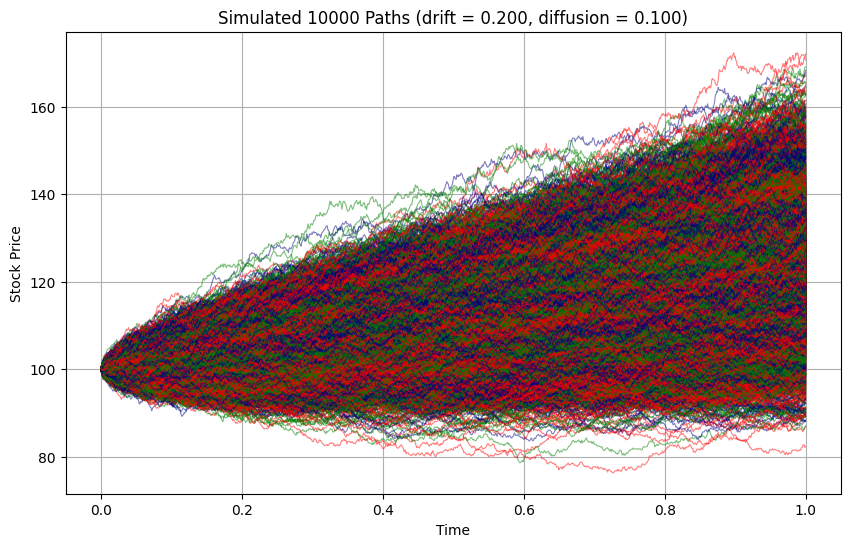

Option Type     |Price  |S0     |K      |r    
euro_call       |12.43  |100.00 |110.00 |0.05
arith_asian_call|2.80   |100.00 |110.00 |0.05
geom_asian_call |2.60   |100.00 |110.00 |0.05
float_lback_call|23.30  |100.00 |110.00 |0.05


In [31]:
# Calculating the Prices for the four types using the following values

S0 = 100 #Spot Price
T = 1 #Time to maturity in years
n_steps = 1000 #Steps to discretization
drift = 0.2 #drift for GBM
diffusion = 0.1 #diffusion for GBM
n_paths = 10000 #number of paths for Monte Carlo Estimation
paths = euler_maruyama_paths(S0, T, n_steps, drift, diffusion, n_paths) #simulating the path


# Plotting the paths
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'navy']
for i in range(n_paths):
    plt.plot(np.linspace(0, T, n_steps + 1), paths[i], lw=0.8, alpha=0.5, color=colors[i%3])
plt.title(f'Simulated {n_paths} Paths (drift = {drift:.3f}, diffusion = {diffusion:.3f})')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.grid()
plt.show()

K = 110 #Strike price to evaluate price of option
rf = 0.05 #risk-free rate for discounting

print(f"Option Type     |Price  |S0     |K      |r    ")
for option in ['euro_call', 'arith_asian_call', 'geom_asian_call', 'float_lback_call']:
    price, payoff = evaluate_option_euler(option, paths, K, T, rf)
    print(f"{option:<16}|{price:<7.2f}|{S0:<7.2f}|{K:<7.2f}|{rf:.2f}")

## Interactive Window
The following cell creates an interactice window where you can tweak parameters, simulate results and price options in an easy-to-use UI.\
**Note**: Run the file to show the interactive window

In [33]:
# Widget to select Option type
message = widgets.HTML("<h1>Interactive Window</h1>")
option_type = widgets.Dropdown(
    options=[('European Call', 'euro_call'),
             ('Arithmetic Asian Call', 'arith_asian_call'),
             ('Geometric Asian Call', 'geom_asian_call'),
             ('Floating Lookback Call', 'float_lback_call')],
    value='euro_call',
    description='Option Type'
)

# Sliders for simulation and pricing params
S0 = widgets.FloatSlider(value=100, min=1, max=500, step=1, description='Current Spot')
drift = widgets.FloatSlider(value=0.2, min=-1.0, max=1.0, step=0.05, description='Drift')
diffusion = widgets.FloatSlider(value=0.2, min=0.01, max=1.0, step=0.01, description='Diffusion')
T = widgets.FloatSlider(value=1.0, min=0.01, max=5.0, step=0.01, description='Time (years)')
n_steps = widgets.IntSlider(value=1000, min=100, max=10000, step=100, description='# Steps')
n_paths = widgets.IntSlider(value=1000, min=0, max=10000, step=100, description='# Paths')
K = widgets.FloatSlider(value=120, min=1, max=500, step=1, description='Strike')
rf = widgets.FloatSlider(value=0.05, min=0.0, max=0.5, step=0.01, description='Risk-free Rate')

# variable to save simulation
simulation = None

# buttons to trigger simulation and pricing
run_button = widgets.Button(description="Run Simulation")
price_button = widgets.Button(description="Price Option")

# Simulation running indicator
running_label = widgets.HTML(value="")  # Empty by default

# output widget to display results
run_output = widgets.Output()
price_output = widgets.Output()
price_output.append_stdout(f"Option Type     |Price  |S0     |K      |r    \n")

# Callback function for the run button click event
def on_run_button_clicked(b):
    running_label.value = "<span style='color:blue; font-weight:bold;'>Simulation running...</span>"
    run_output.clear_output() # Clear previous output

    with run_output:
        # run simulation and save it
        global simulation
        simulation = euler_maruyama_paths(S0.value, T.value, n_steps.value, 
                                          drift.value, diffusion.value, n_paths.value)
        # plot the simulation
        plt.figure(figsize=(10, 6))
        colors = ['red', 'green', 'navy']
        for i in range(n_paths.value):
            plt.plot(np.linspace(0, T.value, n_steps.value + 1), simulation[i], lw=0.8, alpha=0.5, color=colors[i%3])
        plt.title(f'Simulated {n_paths.value} Paths (drift = {drift.value:.3f}, diffusion = {diffusion.value:.3f})')
        plt.xlabel('Time')
        plt.ylabel('Stock Price')
        plt.grid()
        plt.show()

    # set the label to completed
    running_label.value = "<span style='color:green; font-weight:bold;'>Simulation Completed</span>"


# Callback function for the price button click event
def on_price_button_clicked(b):
    # price_output.clear_output() # Clear previous output

    with price_output:
        try:
            # use the saved simulation
            global simulation
            # offseted simulation used to avoid re-simulating when only S0 is varied
            simulation_ = simulation + S0.value - simulation[0,0]
            price, payoff = evaluate_option_euler(option_type.value, simulation_, K.value, T.value, rf.value)
            print(f"{option_type.value:<16}|{price:<7.2f}|{S0.value:<7.2f}|{K.value:<7.2f}|{rf.value:.2f}")
        except(TypeError):
            display(widgets.HTML("<span style='color:red; font-weight:bold;'>Run Simulation First</span>"))

    
# attach the callback function to the run_button and price_button
run_button.on_click(on_run_button_clicked)
price_button.on_click(on_price_button_clicked)

# arrange widgets in a layout
run_box = widgets.VBox([S0, T, drift, diffusion, n_steps, n_paths, run_button, running_label, run_output])
price_box = widgets.VBox([option_type, S0, K, rf, price_button, price_output])
ui = widgets.HBox([run_box, price_box])
ui = widgets.VBox([message, ui])

# display the ui
display(ui)